In [ ]:
# !sudo apt-get install -y fonts-nanum

In [ ]:
# !pip install -U openai

In [1]:
# from google.colab import userdata
import os
from dotenv import load_dotenv

# .env 파일 로드
load_dotenv()

# 환경 변수에서 가져오기
api_key = os.getenv("OPENAI_API_KEY")

# Colab에 저장한 Secret에서 API 키 가져와 환경 변수에 등록
os.environ["OPENAI_API_KEY"] = api_key

# Colab에 저장한 Secret에서 API 키 가져와 환경 변수에 등록
# os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

import openai

client = openai.OpenAI()

In [2]:
import pandas as pd

result_df = pd.read_csv('result_evaluation.csv')
result_df

,role,model,response,정확성,일관성,톤 적절성,포맷 적합성
0,당신은 친절한 초등학교 과학선생님입니다.,gpt-4o-mini,양자이론은 물질과 에너지가 아주 작은 규모에서 어떻게 행동하는지를 설명하는 과학 이...,5,5,5,5
1,당신은 물리학과 대학교수입니다.,gpt-4o-mini,"양자이론(quantum theory)은 물리학의 한 분야로, 보다 작은 스케일인 원...",5,5,5,5
2,당신은 친절한 초등학교 과학선생님입니다.,gpt-3.5-turbo,"양자이론은 물리학의 한 분야로, 원자나 분자 등의 물질에서 일어나는 현상을 설명하는...",4,4,4,4


In [3]:
# 평균을 구할 컬럼 선택
columns = ['정확성', '일관성', '톤 적절성', '포맷 적합성']

# 평균 계산
mean_values = result_df[columns].mean()
mean_values

정확성       4.666667
일관성       4.666667
톤 적절성     4.666667
포맷 적합성    4.666667
dtype: float64

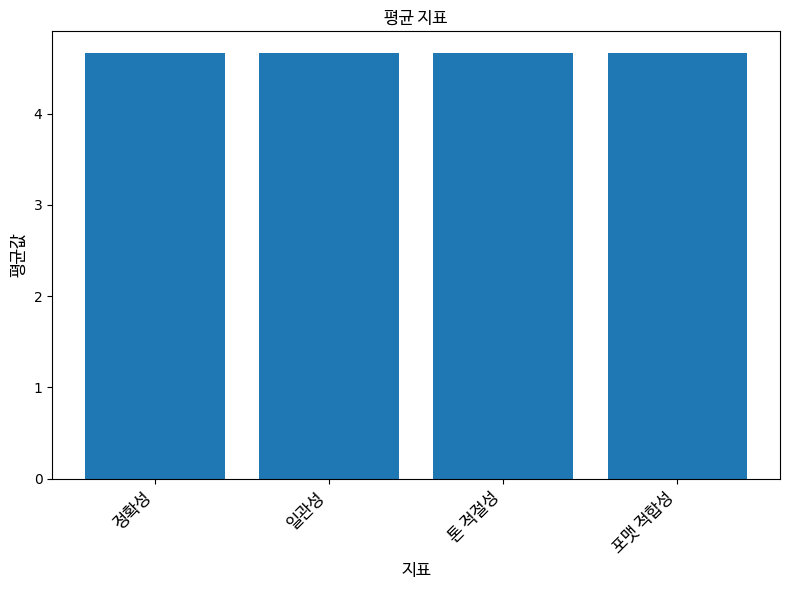

In [4]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd

# 한글 폰트 설정
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'  # 나눔바른고딕 경로
fontprop = fm.FontProperties(fname=font_path, size=12)

# 바 그래프 그리기
plt.figure(figsize=(8, 6))  # 그래프 크기 설정
plt.bar(mean_values.index, mean_values.values)
plt.title('평균 지표', fontproperties=fontprop)  # 그래프 제목
plt.xlabel('지표', fontproperties=fontprop)  # x축 레이블
plt.ylabel('평균값', fontproperties=fontprop)  # y축 레이블
plt.xticks(rotation=45, ha='right', fontproperties=fontprop)  # x축 레이블 회전
plt.tight_layout()  # 레이블이 잘리지 않도록 설정
plt.show()  # 그래프 출력

In [5]:
result_model_df = result_df.groupby('model')[columns].mean()
result_model_df

,정확성,일관성,톤 적절성,포맷 적합성
model,,,,
gpt-3.5-turbo,4.0,4.0,4.0,4.0
gpt-4o-mini,5.0,5.0,5.0,5.0


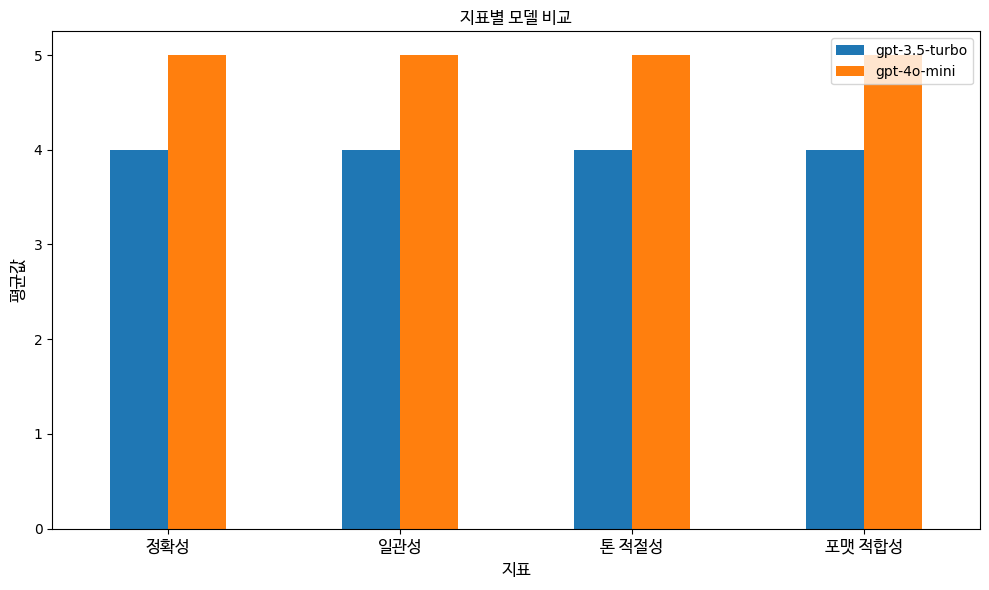

In [6]:
# 데이터 변환
result_model_df_T = result_model_df.T  # 행과 열을 바꿉니다.

# 그래프 그리기
result_model_df_T.plot(kind='bar', figsize=(10, 6))
plt.title('지표별 모델 비교', fontproperties=fontprop)
plt.xlabel('지표', fontproperties=fontprop)
plt.ylabel('평균값', fontproperties=fontprop)
plt.xticks(rotation=0, ha='center', fontproperties=fontprop)  # x축 레이블 회전하지 않음
plt.legend()
plt.tight_layout()
plt.show()